<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 3
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Black-Scholes Monte Carlo
</h2>

This notebook aims to compare the prices of European call and put options obtained by simulating the time evolution of the asset price (modeled by a Geometric Brownian Motion) in two different ways:
- directly sampling the final asset price;
- discretizing its time evolution;

The results will be compared with the values predicted by the Black-Scholes-Merton (BSM) analytical formula.

<p style="color: blue; font-size: 25px; font-weight: bold;">
Wiener processes
</p>

The study of natural processes that exhibit stochastic behavior led to the development of new mathematical tools, known as stochastic calculus. This framework extends the formalism of ordinary differential equations to deal with trajectories that are continuous but non-differentiable, capturing systems that evolve in a non-deterministic manner.

Norbert Wiener provided a rigorous foundation for this process, showing that it can be modeled as a random walk with stationary, independent and identically distributed Gaussian increments, $W(t)-W(s) \sim \mathcal{N}(0, t-s)$. This naturally leads to
$$
W(t_{i+1})=W(t_i)+Z_{i+1}\sqrt{t_{i+1}-t_i},
$$
with $Z_i\simeq\mathcal{N}(0, 1)$.

# Geometric Brownian motion

We define a Generic Brownian Motion with drift $\mu$ and diffusion coefficient $\sigma$ a stochastic process 
$$
X\sim\mathcal{BM}(\mu, \sigma^2),
$$
if
$$
\frac{X(t)-t\mu}{\sigma}\simeq\mathcal{BM}(0, 1),
$$
where $\mathcal{BM}(0, 1)$ is a Wiener Process (Standard Brownian Motion).
It reduces to the standard Brownian motion when $\mu=0$ and $\sigma=1$.
The definition above implies several properties:
- The process is a functional of a Wiener process and its evolution is governed by the Itô SDE (using Itô formula):
$$
dX(t)=\mu dt+\sigma dW(t).
$$
- Since a Wiener Process $W(t)$ is distributed as $\mathcal{N}(0, t)$ and it's self-similar, the geometric Brownian motion $X(t)$ is distributed as $\mathcal{N}(\mu t, \sigma^2t)$.
- Its path can be sampled exactly using the increment formula of the Wiener process sampling:
$$
X(t_{i+1})=X(t_i)+\mu (t_{i+1}-t_i)+\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}.
$$

<p style="color: blue; font-size: 25px; font-weight: bold;">
Application to financial markets
</p>

A market is a place where buyers and sellers meet to exchange goods, each of which has a price at every moment in time, called the spot price.
This price results from the interaction between supply and demand.

European options are the simplest type of derivate contracts in the financial market. They represent an agreement between two parties in which the writer (the seller of the option) grants the holder (the buyer of the option) the right, but not the obligation, to purchase (call option) from him or to sell (put option) to him an underlying asset for a prescripted price **K (strike price)** at the expiry date T. The holder will exploit his right only if he gains a profit:
- he will perform a call option only if $K\leq S(t)$, so that he can buy an asset at a lower price from the writer and sell to the market at an higer price
$$
P_{call}=\max[0, S(T)-K];
$$
- he will perform a put option only if $K\geq S(t)$ so that he can buy an asset at a lower price from the market and sell to the writer at an higer price
$$
P_{put}=\max[0, K-S(T)].
$$

The main challenge is to correctly determine the fair price of these contracts.
For European options, however, the Black–Scholes theory provides a closed-form solution.

<p style="color: blue; font-size: 25px; font-weight: bold;">
Brownian Motion and Monte Carlo Simulation
</p>

To evaluate an option using Monte Carlo simulation, the procedure is:
- Generate multiple simulated paths of the asset price 
- Compute the payoff for each simulated path
- Average the payoffs (data blocking), discounted to time $t=0$ with the factor $e^{-\mu T}$

# 1. Direct sampling
The terminal price $S(T)$ can be generated directly from the closed-form solution of the Geometric Brownian Motion
$$
S(T)=S_0e^{\bigg[\big(\mu-\frac{\sigma^2}{2}\big)T+\sigma z \sqrt{T}\bigg]},
$$
where $z\sim\mathcal{N}(0, 1)$.

# 2. Discretized sampling
Alternatively, the time interval $[0, T]$ is divided into $N$ sub-intervals, and the asset price is simulated step by step
$$
S(t+\Delta t)=S(t)e^{\bigg[\big(\mu-\frac{\sigma^2}{2}\big)\Delta t+\sigma z \sqrt{\Delta t}\bigg]},
$$
where again $z\sim\mathcal{N}(0, 1)$.

Results below show the Monte Carlo calculated values for discrete and continuous sampling for call and put. A comparison with the analytical solution derived in the Black-Scholes theory shows the reliability of the results obtained.

```text
 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364
```

# simulation parameters
```text
TOTAL SAMPLES        N         100000
BLOCK NUMBER         N_BLOCK   100
INITIAL SPOT PRICE   S(0)      100
STRIKE PRICE         K         100
EXPIRY TIME          T         1
RISK FREE RATE       MU        0.1
DIFFUSION/VOLATILITY SIGMA     0.25
TIME STEP            N_STEP    100
```


In [5]:
import numpy as np
import matplotlib.pyplot as plt

data_discrete_call = np.loadtxt("./OUTPUT/discrete_call.dat", skiprows=1)
data_discrete_put = np.loadtxt("./OUTPUT/discrete_put.dat", skiprows=1)
data_GBM_call = np.loadtxt("./OUTPUT/GBM_call.dat", skiprows=1)
data_GBM_put = np.loadtxt("./OUTPUT/GBM_put.dat", skiprows=1)

N = data_discrete_call[:, 0]
call_discr = data_discrete_call[:, 1]
err_call_discr = data_discrete_call[:, 2]
put_discr = data_discrete_put[:, 1]
err_put_discr = data_discrete_put[:, 2]

call_GBM = data_GBM_call[:, 1]
err_call_GBM = data_GBM_call[:, 2]
put_GBM = data_GBM_put[:, 1]
err_put_GBM = data_GBM_put[:, 2]

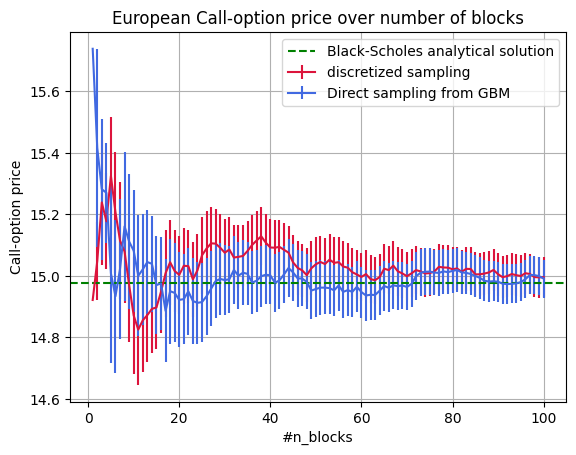

In [6]:
plt.errorbar(N, call_discr, yerr=err_call_discr, color='crimson', label='discretized sampling')
plt.errorbar(N, call_GBM, yerr=err_call_GBM, color='royalblue', label='Direct sampling from GBM')
plt.axhline(14.975790778311286, color='g', linestyle='--', label='Black-Scholes analytical solution')
plt.xlabel("#n_blocks")
plt.ylabel("Call-option price")
plt.grid(True)
plt.legend()
plt.title("European Call-option price over number of blocks")
plt.show()

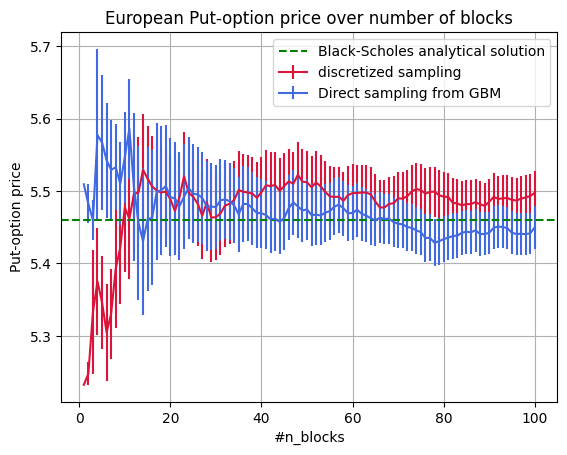

In [7]:
plt.errorbar(N, put_discr, yerr=err_put_discr, color='crimson', label='discretized sampling')
plt.errorbar(N, put_GBM, yerr=err_put_GBM, color='royalblue', label='Direct sampling from GBM')
plt.axhline(5.4595325819072364, color='g', linestyle='--', label='Black-Scholes analytical solution')
plt.xlabel("#n_blocks")
plt.ylabel("Put-option price")
plt.grid(True)
plt.legend()
plt.title("European Put-option price over number of blocks")
plt.show()

Both simulations results demonstrate excellent agreement with the analytical BSM price, statistically consistent with the expected analytical value.

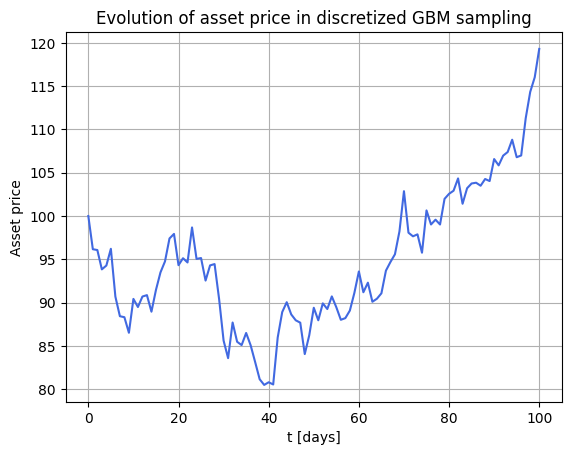

In [8]:
data_evolution = np.loadtxt("./OUTPUT/asset_price_evolution.dat", skiprows=1)
time = data_evolution[:, 0]
price = data_evolution[:, 1]
plt.plot(time, price, color='royalblue')
plt.xlabel("t [days]")
plt.ylabel("Asset price")
plt.title("Evolution of asset price in discretized GBM sampling")
plt.grid(True)
plt.show()